# Primary Vertex check

The discrepancy we see in the transverse impact parameter might come fromt the fact, that the primary vertices are off. 

Created my own data, check `/eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_debug_tracks/without_beamspot_constraint` with 

```
k4run CLDReconstruction.py --inputFiles /eos/experiment/fcc/prod/fcc/ee/test_spring2024/240gev/Huu/CLD_o2_v05/sim/00016822/000/Huu_sim_*.root \
                           --outputBasename /eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_debug_tracks/without_beamspot_constraint/Huu_beamspotcontraintFalse \
                           -n 1000 \
                           --cms 240 \
                           --enableLCFIJet
```


And modified `"PrimaryVertexFinder.BeamspotConstraint": ["0"]` (before 1). 

In [1]:
import uproot 
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator, FuncFormatter

import gc

from sklearn.metrics import roc_curve, auc, roc_auc_score
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

%load_ext autoreload
%autoreload 2

In [20]:
from scipy.optimize import curve_fit

In [2]:
from cycler import cycler
import matplotlib

# Set the color cycle
# https://coolors.co/542344-f68e5f-e5e059-007ea7-98e2c6
plt.rc('axes', prop_cycle=cycler('color', ['#73b06f', '#e6701b', '#007090', '#e7298a', '#802392', '#ffad08', '#56b4e9']))
matplotlib.rcParams["font.family"] = "serif"
# Set font sizes
matplotlib.rcParams.update(
    {
        "font.size": 14,  # General font size
    }
)

In [3]:
path_fullsim = "/eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_debug_tracks/without_beamspot_constraint/Huu.root"
path_fastsim = "/eos/experiment/fcc/ee/jet_flavour_tagging/winter2023/samples_v7/CLD_Huu_debug_tracks/stage1_Huu.root" #Huu.root"

In [4]:
def load_data(file_name, stop=250000, key='tree;1'):
    file = uproot.open(file_name)
    tree = file[key]
    data = tree.arrays(library="np", entry_start=0, entry_stop=stop)
    return data

In [5]:
dic = {"fast": load_data(path_fastsim, stop=2000, key='events;1'), "full": load_data(path_fullsim, stop=2000, key="JetConstituentObservables;1"),} # 100k, 500k

In [6]:
dic["full"].keys()

dict_keys(['pfcand_erel_log', 'pfcand_thetarel', 'pfcand_phirel', 'pfcand_e', 'pfcand_p', 'pfcand_type', 'pfcand_charge', 'pfcand_isEl', 'pfcand_isMu', 'pfcand_isGamma', 'pfcand_isChargedHad', 'pfcand_isNeutralHad', 'pfcand_dndx', 'pfcand_tof', 'pfcand_cov_omegaomega', 'pfcand_cov_tanLambdatanLambda', 'pfcand_cov_phiphi', 'pfcand_cov_d0d0', 'pfcand_cov_z0z0', 'pfcand_cov_d0z0', 'pfcand_cov_phid0', 'pfcand_cov_tanLambdaz0', 'pfcand_cov_d0omega', 'pfcand_cov_d0tanLambda', 'pfcand_cov_phiomega', 'pfcand_cov_phiz0', 'pfcand_cov_phitanLambda', 'pfcand_cov_omegaz0', 'pfcand_cov_omegatanLambda', 'pfcand_d0', 'pfcand_d0_wrt_000', 'pfcand_z0', 'pfcand_Sip2dVal', 'pfcand_Sip2dSig', 'pfcand_Sip3dVal', 'pfcand_Sip3dSig', 'pfcand_JetDistVal', 'pfcand_JetDistSig', 'jet_PV_x', 'jet_PV_y', 'jet_PV_z', 'jet_PV_id', 'jet_MCPV_x', 'jet_MCPV_y', 'jet_MCPV_z'])

In [7]:
dic["fast"]["jet_PV_x"].shape, dic["full"]["jet_PV_x"].shape

((2000,), (2000,))

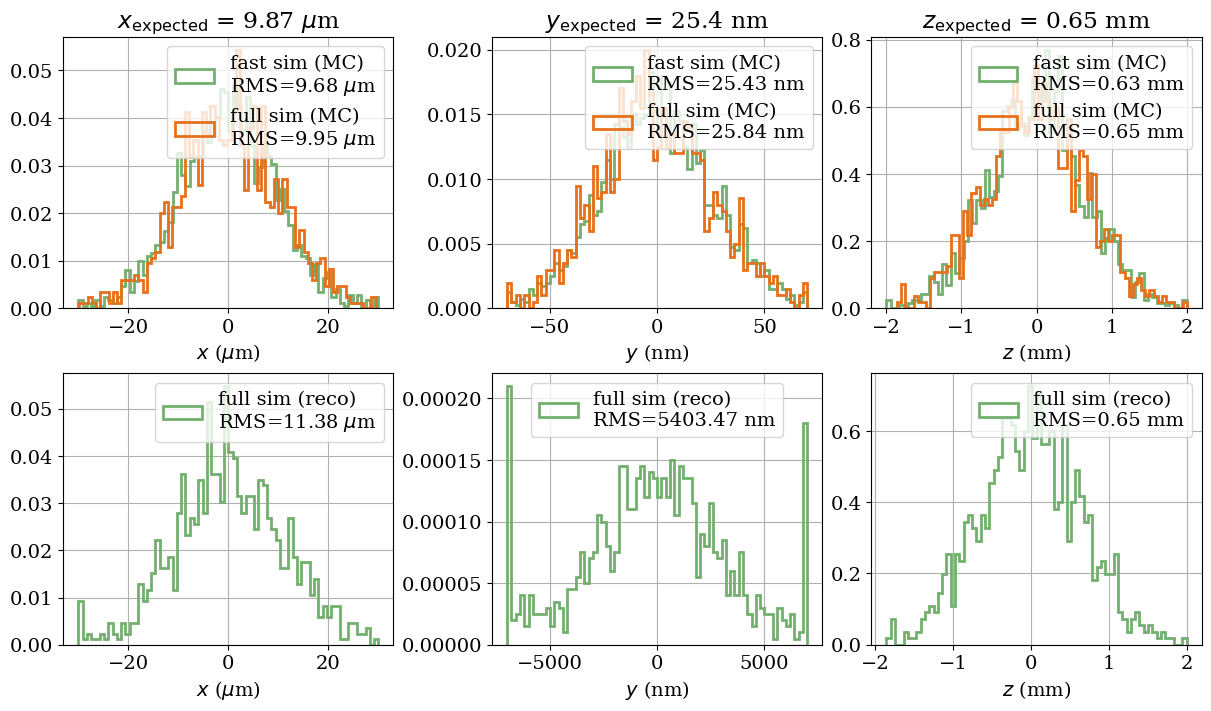

In [10]:
keys = ["jet_PV_x", "jet_PV_y", "jet_PV_z"]
MCkeys = ["jet_MCPV_x", "jet_MCPV_y", "jet_MCPV_z"]
xlabels = [r"$x$ ($\mu$m)", "$y$ (nm)", "$z$ (mm)"]
units = ["$\mu$m", "nm", "mm"]
legend_labels = {"fast": "(MC)", "full": "(reco)"}
ranges = {"full":{
    "jet_PV_x": (-30, 30), #(-3e-3, 3e-3),
    "jet_PV_y": (-7000, 7000),
    "jet_PV_z": (-2, 2),
}, "fast": {
    "jet_PV_x": (-30, 30),#(-30, 30), #(-3e-3, 3e-3),
    "jet_PV_y": (-70, 70),
    "jet_PV_z": (-2, 2),
}
}
multipliers = {
    "jet_PV_x": 1e3,
    "jet_PV_y": 1e6,
    "jet_PV_z": 1,
}

bins = 70

fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

# Add headers
for i, header in enumerate([r"$x_\mathrm{expected}$ = 9.87 $\mu$m", r"$y_\mathrm{expected}$ = 25.4 nm", r"$z_\mathrm{expected}$ = 0.65 mm"]):
    ax[0, i].set_title(header)

for j, ff in enumerate(dic.keys()):
    for i, key in enumerate(keys):

        data = dic[ff][key] * multipliers[key] 
        rms = np.sqrt(np.mean(data**2))

        # overflow bins
        d = np.clip(data, ranges[ff][key][0], ranges[ff][key][1])

        ax[j,i].hist(d, bins=bins, histtype="step", label="{} sim {}\nRMS={:.2f} {}".format(ff, legend_labels[ff], rms, units[i]), density=True, linewidth=2)

        if ff == "full":
            dataMC = dic[ff][MCkeys[i]] * multipliers[key]
            rmsMC = np.sqrt(np.mean(dataMC**2))
            dMC = np.clip(dataMC, ranges["fast"][key][0], ranges["fast"][key][1])
            ax[0,i].hist(dMC, bins=bins, histtype="step", label="full sim (MC) \nRMS={:.2f} {}".format(rmsMC, units[i]), density=True, linewidth=2)
            ax[0,i].legend()

        ax[j,i].grid()
        ax[j,i].set_xlabel(xlabels[i])
        ax[j,i].legend()
        
#plt.tight_layout()
plt.show()

Expected at 250 GeV: $x = 9.87$ $\mu$ m, $y= 25.4$ nm, $z= 0.65$ mm

## Check how d0 looks with this?

In [13]:
path_fullsim = "/eos/experiment/fcc/ee/datasets/CLD_fullsim_tagging_debug_tracks/without_beamspot_constraint/Huu.root" # same as above
path_fastsim = "/eos/experiment/fcc/ee/jet_flavour_tagging/winter2023/samples_v7/CLD_Huu_debug_tracks/Huu_withoutPV.root" # change to stage 2 fast sim file

In [15]:
dic = {"fast": load_data(path_fastsim, stop=2000, key='tree;1'), "full": load_data(path_fullsim, stop=2000, key="JetConstituentObservables;1"),} # 100k, 500k

In [11]:
def get_index_charged_particles(df, ptype='cpart'):
    """Choose particle type: cpart, npart, photon"""
    if df == 'fast':
        types = dic[df]['pfcand_type']
        if ptype=='cpart':
            num = [0]
        elif ptype=='npart':
            num = [130]
        elif ptype=='photon':
            num = [22]
    elif df == 'full':
        types = dic[df]['pfcand_type']
        if ptype=='cpart':
            num = [-211, -13, -11, 11, 13, 211] 
        elif ptype=='npart':
            num = [2112]
        elif ptype=='photon':
            num = [22]
    mask_bool_chad = []
    for i in range(types.shape[0]):
        index = np.where(np.isin(types[i], num))[0]
        bool_list = np.zeros(len(types[i]), dtype=bool)
        bool_list[index] = True
        mask_bool_chad.append(bool_list)
    return mask_bool_chad

def get_value_highest_energy_particle(df, k=3, ptype='cpart', debug=False):
    """return the index of the k highest energy charged particle in each event"""
    if df == 'fast':
        particles_e = dic[df]['pfcand_e']
        mask_chad = get_index_charged_particles('fast', ptype=ptype)
    elif df == 'full':
        particles_e = dic[df]['pfcand_e']
        mask_chad = get_index_charged_particles('full', ptype=ptype)
    index_charged = []
    for i  in range(particles_e.shape[0]):
        part_e = particles_e[i]
        ind = np.argsort(part_e)[::-1]
        mask = mask_chad[i]
        c_index = np.arange(len(part_e))[mask] # indicies with charged/neutral particles
        # now order the charged/neutral particles by energy with ind
        index_map = {value: np.where(ind == value)[0][0] for value in c_index}
        sorted_c_index = sorted(c_index, key=lambda x: index_map[x])
        index_charged.append(sorted_c_index[:k])
        if debug and i==1:
            print("part_e: ", part_e)
            print("mask: ", mask)
            print("ind: ", ind)
            print("index_map: ", index_map)
            print("c_index: ", c_index)
            print("sorted_c_index: ", sorted_c_index)
    return index_charged

def get_chad_elements(df_value, index):
    e_1 = []
    e_2 = []
    e_3 = []
    for i in range(len(df_value)):
        index_list = index[i] # this can have 1, 2 or 3 elements
        if len(index_list) == 1:
            e_1.append(df_value[i][index_list[0]])
        elif len(index_list) == 2:
            e_1.append(df_value[i][index_list[0]])
            e_2.append(df_value[i][index_list[1]])
        elif len(index_list) == 3:
            e_1.append(df_value[i][index_list[0]])
            e_2.append(df_value[i][index_list[1]])
            e_3.append(df_value[i][index_list[2]])
    return [np.array(e_1), np.array(e_2), np.array(e_3)]

In [16]:
index_charged_3E_full = get_value_highest_energy_particle("full")
index_charged_3E_fast = get_value_highest_energy_particle("fast")

In [17]:
def gaus_fit(containers, n_counts, label):
    # label should be '{L}' or '{NN}'
    x_centers = 0.5*(containers[:-1]+containers[1:])
    maxv = n_counts.max()
    ind_fit = np.where(n_counts[1:-2] > 0.15*maxv) # exclude the first and last bin because they are from the overflow
    liml = ind_fit[0].min()
    limu = ind_fit[0].max() + 1

    popt, pcov = curve_fit(gaus, x_centers[liml:limu], n_counts[liml:limu], p0=[0,1, 100], sigma=1/np.sqrt(n_counts)[liml:limu], maxfev=10000)
    perr = np.sqrt(np.diag(pcov))
    a1_fit = np.linspace(x_centers[liml:limu][0], x_centers[liml:limu][-1], 500)
    a2_fit = gaus(a1_fit, *popt)
    ax.plot(a1_fit, a2_fit, '--', label= r"$\mu_{} = ({:.2f} \pm {:.2f})\mu$m".format(label, popt[0]*10**3, perr[0]*10**3) + "\n" + r"$\sigma_{} = ({:.2f} \pm {:.2f})\mu$m".format(label, popt[1]*10**3, perr[1]*10**3))
    return popt, perr

def gaus(x, mu, sigma, A):
    return (A/np.sqrt(2*np.pi * sigma**2))* np.exp(-(x-mu)**2 / (2*sigma**2))

def plot_with_fit(ax, val, bins, k, r):
    fit_values = np.zeros(4) # mu, simga and then uncertainties

    n_counts, containers, patches = ax.hist(val, bins=bins, histtype='step', label=k, density=True, linewidth=2.0, range=r)
    popt, perr = gaus_fit(containers, n_counts, label='')
    fit_values = np.array([popt[0], popt[1], perr[0], perr[1]])

    return fit_values.reshape((2,2))

In [18]:
def get_IP_params(dic, k, index_charged):
    """ Get the 5 track parameters for the highest energy charged particle"""
    data = dic[k]
    if k == "full":
        d0 = get_chad_elements(data['pfcand_d0'], index_charged)[0]
        z0 = get_chad_elements(data['pfcand_z0'], index_charged)[0]
    elif k== "fast":
        d0 = get_chad_elements(data['pfcand_dxy'], index_charged)[0]
        z0 = get_chad_elements(data['pfcand_dz'], index_charged)[0]

    return d0, z0


[[-9.35880226e-05  3.01842576e-03]
 [ 9.63171840e-05  1.20836402e-04]]
[[-8.89529331e-05  3.30114589e-03]
 [ 1.15238849e-04  1.37512122e-04]]
[[-8.39232898e-05  2.43198629e-03]
 [ 1.21512868e-04  1.41923002e-04]]
[[-7.49003947e-05  2.57852604e-03]
 [ 1.35541866e-04  1.54768096e-04]]


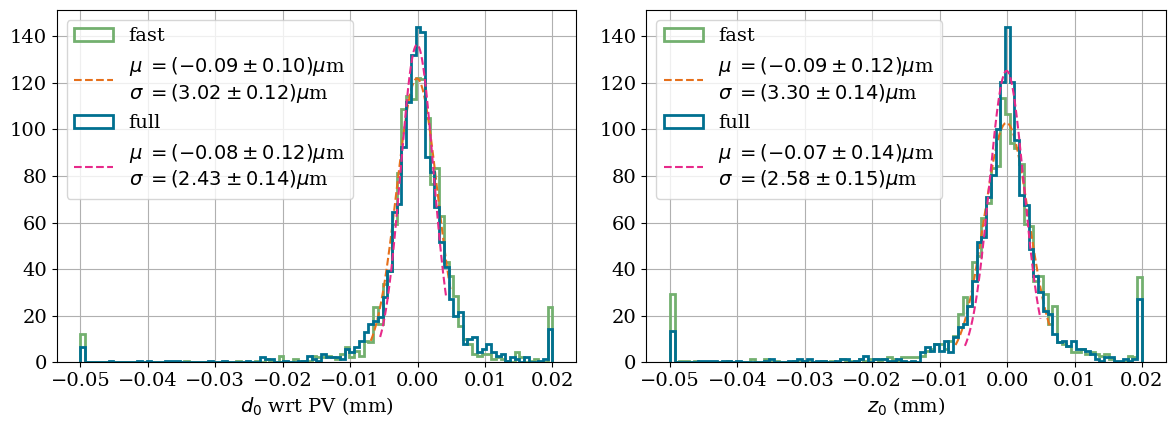

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
labels = [r"$d_0$ wrt PV (mm)", "$z_0$ (mm)"]
ranges = [(-0.05, 0.02), (-0.05, 0.020)]
bins = 100
for k in dic.keys():
    if k == "full":
        d0, z0 = get_IP_params(dic, k, index_charged_3E_full)
    elif k == "fast":
        d0, z0 = get_IP_params(dic, k, index_charged_3E_fast)
    else:
        raise ValueError("Wrong key") 

    # overflow and underflow bins

    d0 = np.clip(d0, ranges[0][0], ranges[0][1])
    z0 = np.clip(z0, ranges[1][0], ranges[1][1])


    # plot the 5 track parameters
    axs = axs.ravel()
    for i, ax in enumerate(axs):
        # plot the histograms
        if i == 8 or i == 7:
            continue
        fits = plot_with_fit(ax, [d0, z0][i], bins, k, ranges[i])
        print(fits)
        #ax.hist([d0, z0][i], bins=bins, histtype='step', label=k, density=True, linewidth=2.0, range=ranges[i])
        ax.set_xlabel(labels[i])
        ax.legend(loc='upper left')
        ax.grid(True)
        #ax.set_ylim(0,120)
plt.tight_layout()
save=False
if save==True: 
    plt.savefig("plots/Huu_d0z0_gausfit.pdf")
plt.show()
